In [10]:
library(tidyverse)
library(forecast)

#-----------------
options(
    repr.plot.width = 14,
    repr.plot.height = 9
)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.2.1     v readr     2.2.0
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.3     v tibble    3.3.1
v lubridate 1.9.5     v tidyr     1.3.2
v purrr     1.2.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Load and pre-process data from [Danmarks Statistik](https://www.dst.dk/da/)

In [11]:
data_full <- read.csv("data_danmarks_statistik/danish_milk_production.csv", na = '..')

In [12]:
glimpse(data_full)

Rows: 372
Columns: 16
$ date                                                                                       <chr> ~
$ Milk.ex.farm..total..m.kg.                                                                 <dbl> ~
$ Delivered.milk.to.dairies..m.kg.                                                           <dbl> ~
$ Delivered.organic.milk.to.dairies..m.kg.                                                   <dbl> ~
$ Avarage.fat.content.of.delivered.milk.to.the.dairies..percent.                             <dbl> ~
$ Avarage.protein.content.of.delivered.milk.to.dairies..percent.                             <dbl> ~
$ Milk.ex.farm..total..DK.ore.per.kg.                                                        <dbl> ~
$ Milk.ex.farm.with.4.2..fat.content.and.3.4.protein.content..DK.ore.pr..kg.                 <dbl> ~
$ Milk.ex.farm..total..DKK.Mio.                                                              <dbl> ~
$ Production.of.butter..m.kg.                                        

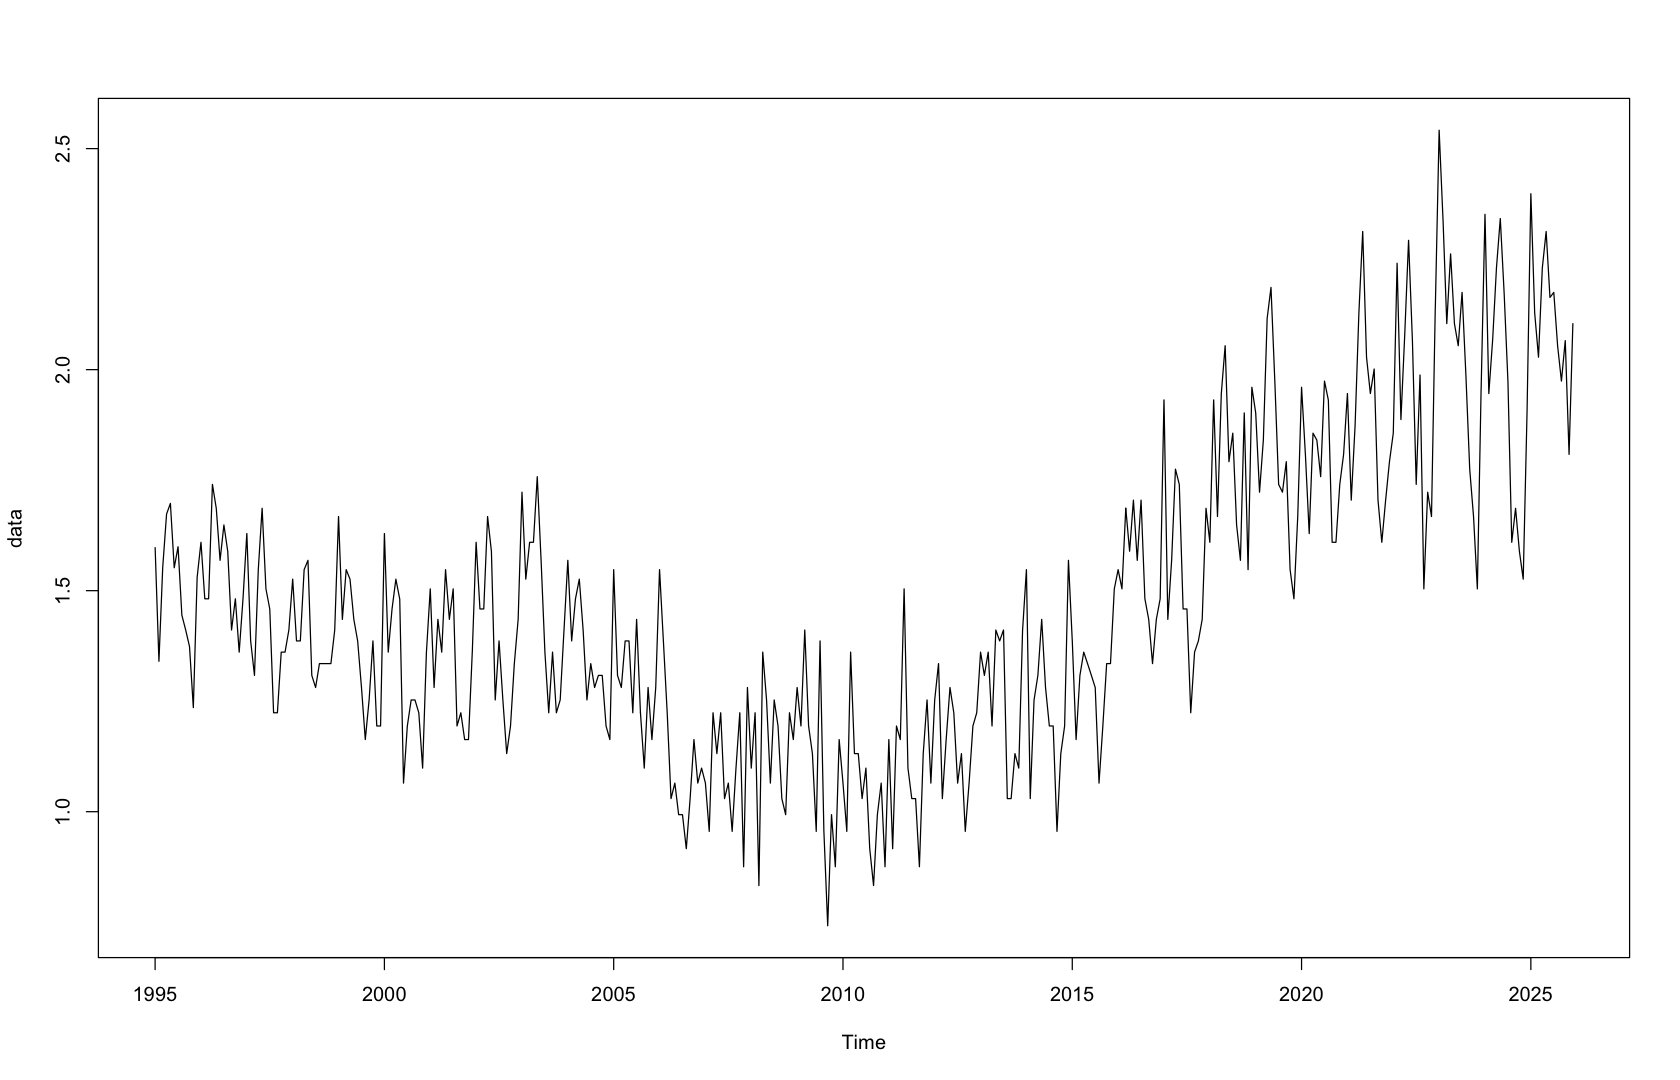

In [59]:
data <- ts(data_full$Production.of.butter..m.kg.,
                start = c(1995, 1),
                frequency = 12,
                )

#--------------------------------------------------------
# Crop the data if needed
# data <- window(data, start = 2007)

# Log-transform if variance changes with time
data <- log(data)

plot(data)

## Split into training and testing data (for forecasting), 95% and 5%, respectively

In [81]:
n <- length(data)
n_train <- floor(0.95 * n) # 95% of the data are training data
#---------------
data_train <- window(data, end = time(data)[n_train])
data_test  <- window(data, start = time(data)[n_train + 1])

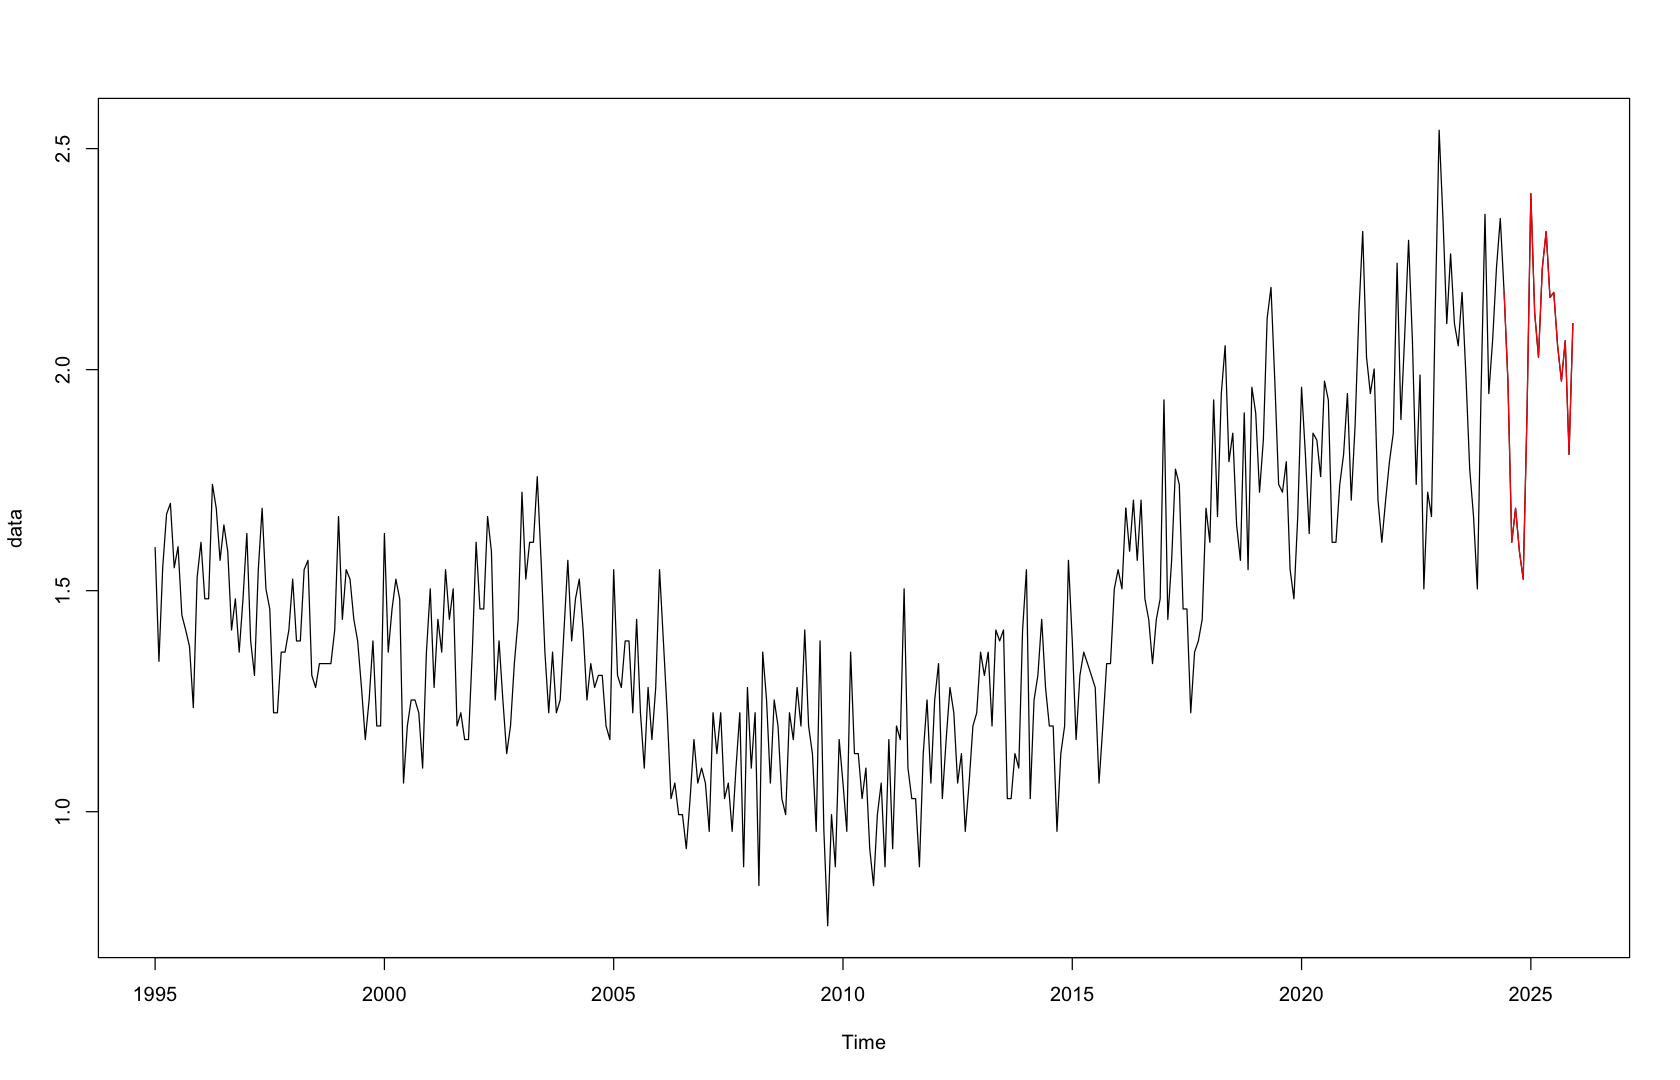

In [82]:
plot(data)
lines(data_test, col = 'red')

***

## Check ACF and PACF

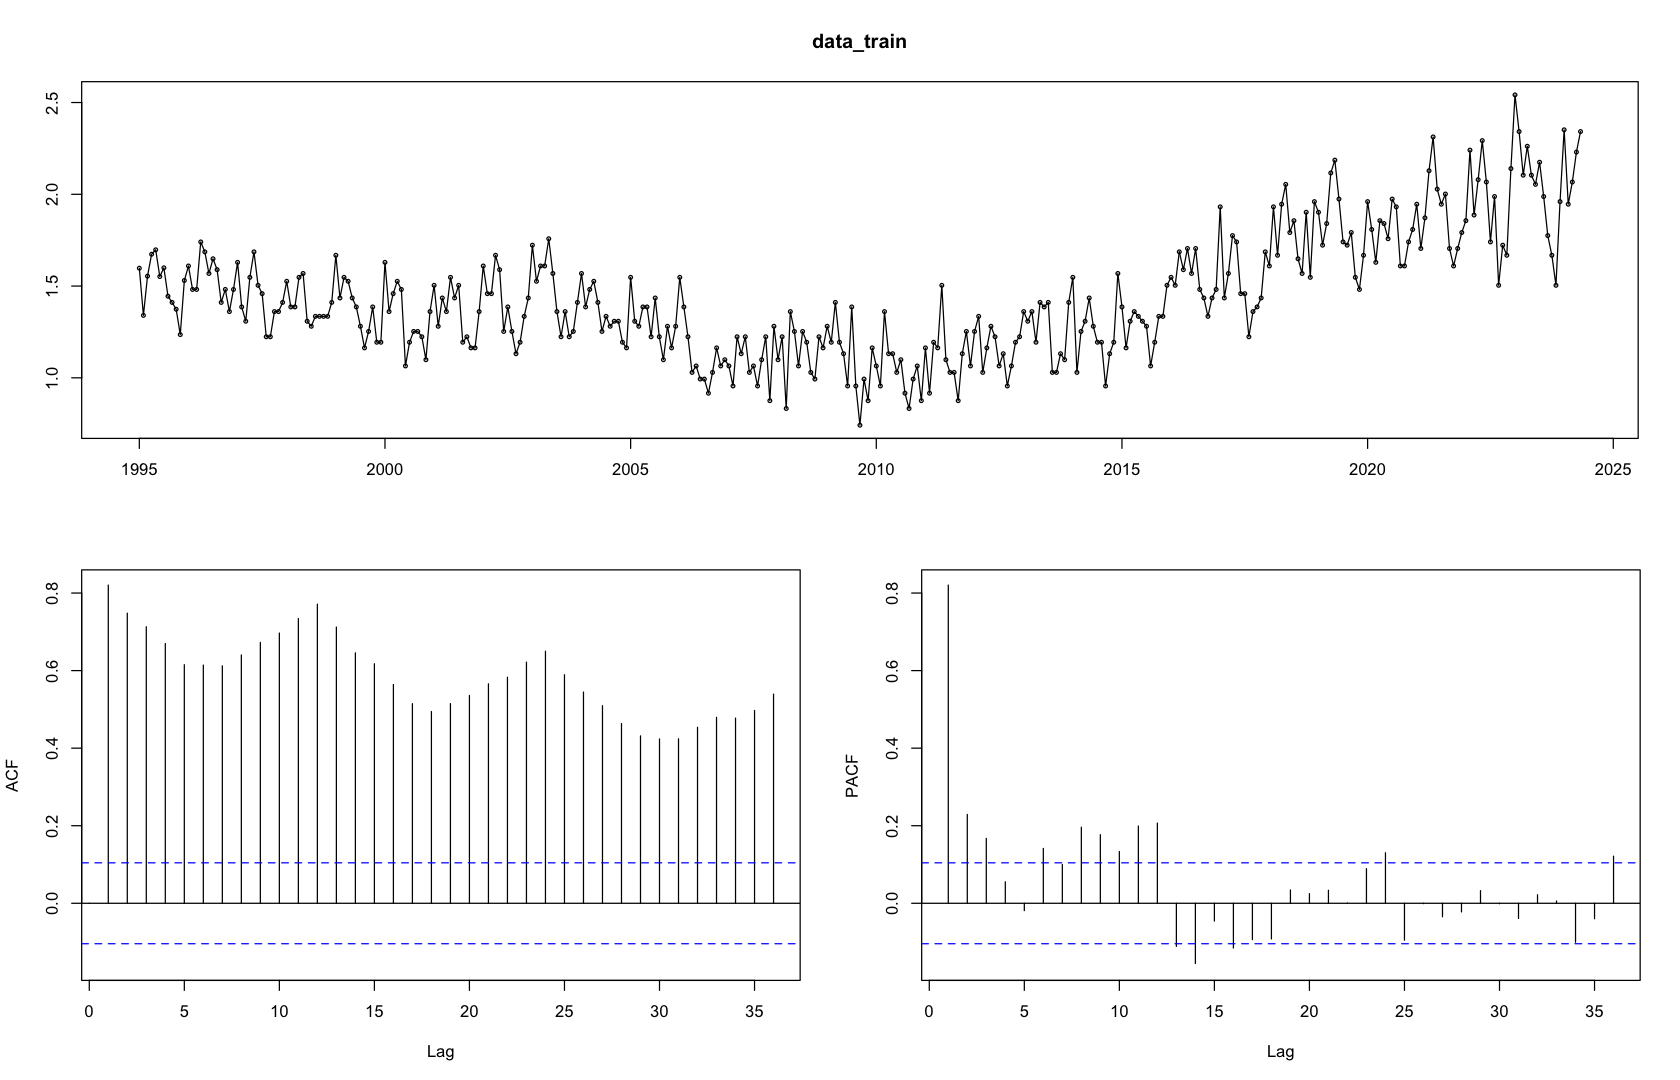

In [83]:
tsdisplay(data_train)

## Test for stationarity

In [84]:
library(tseries)

adf.test(data_train)


	Augmented Dickey-Fuller Test

data:  data_train
Dickey-Fuller = -2.1188, Lag order = 7, p-value = 0.5267
alternative hypothesis: stationary


## Test for seasonality

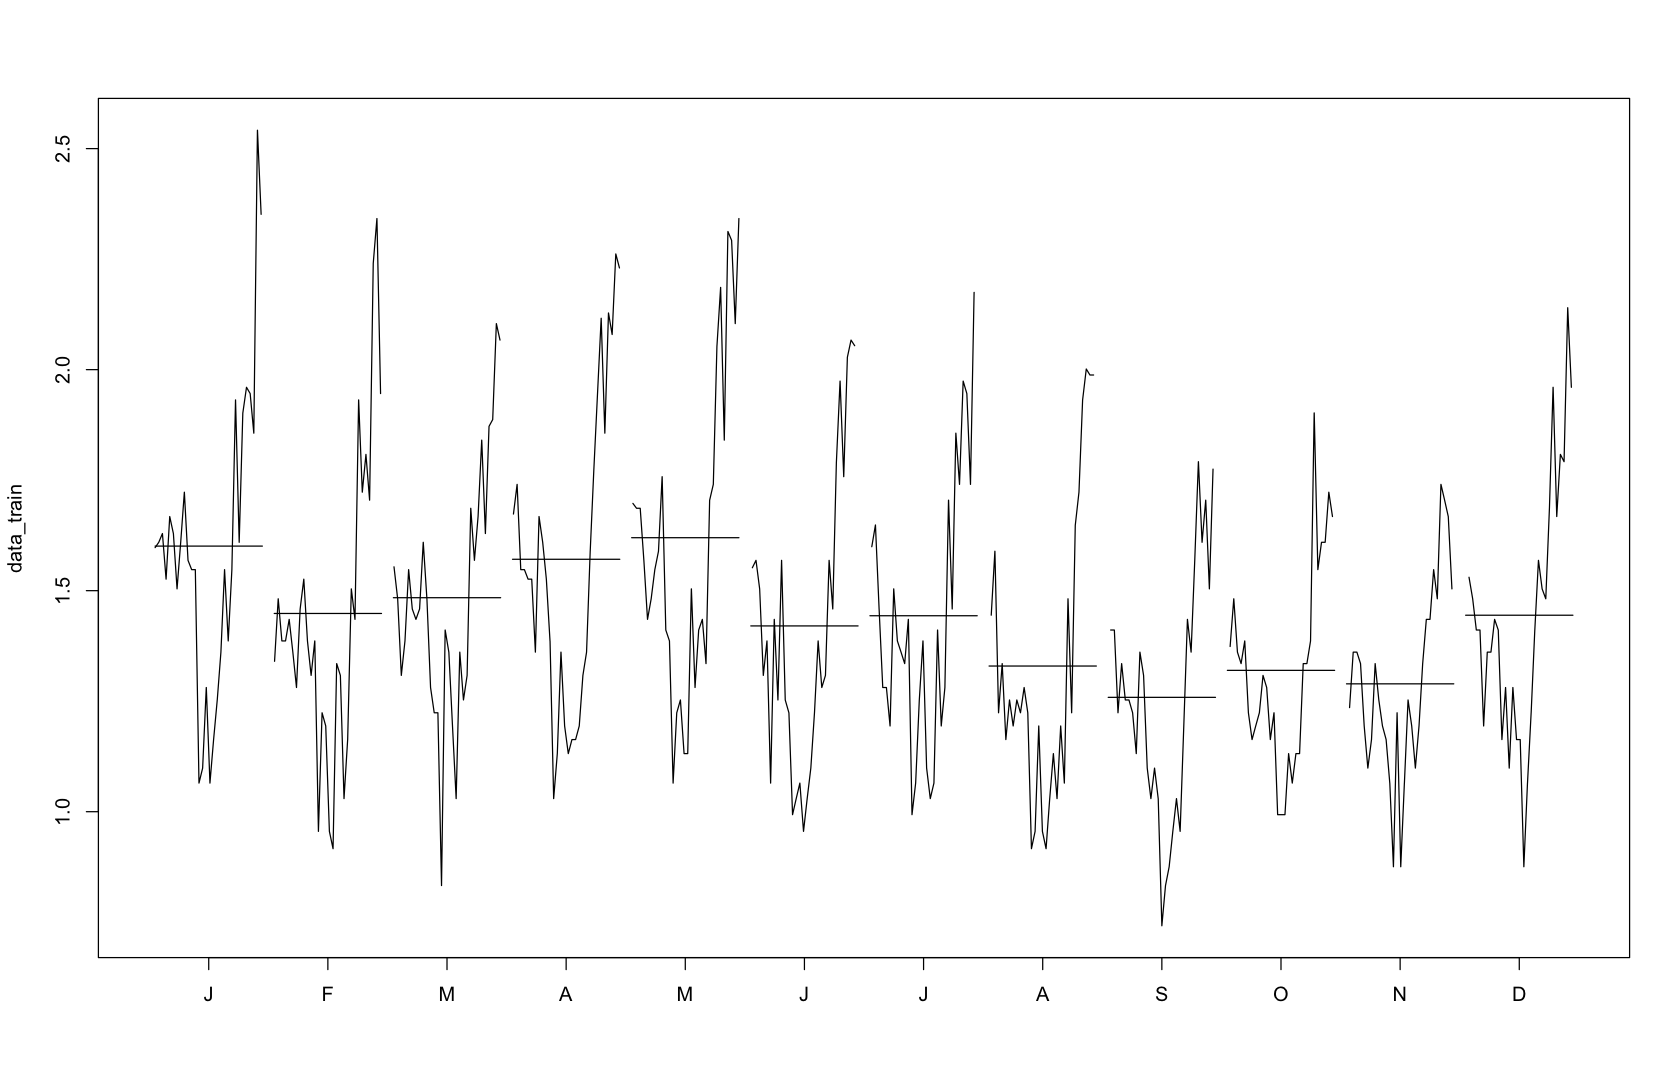

In [85]:
monthplot(data_train)

## Time series is non-stationary with a clear seasonal trend

***

## Seasonal-Trend decomposition using LOESS (STL)

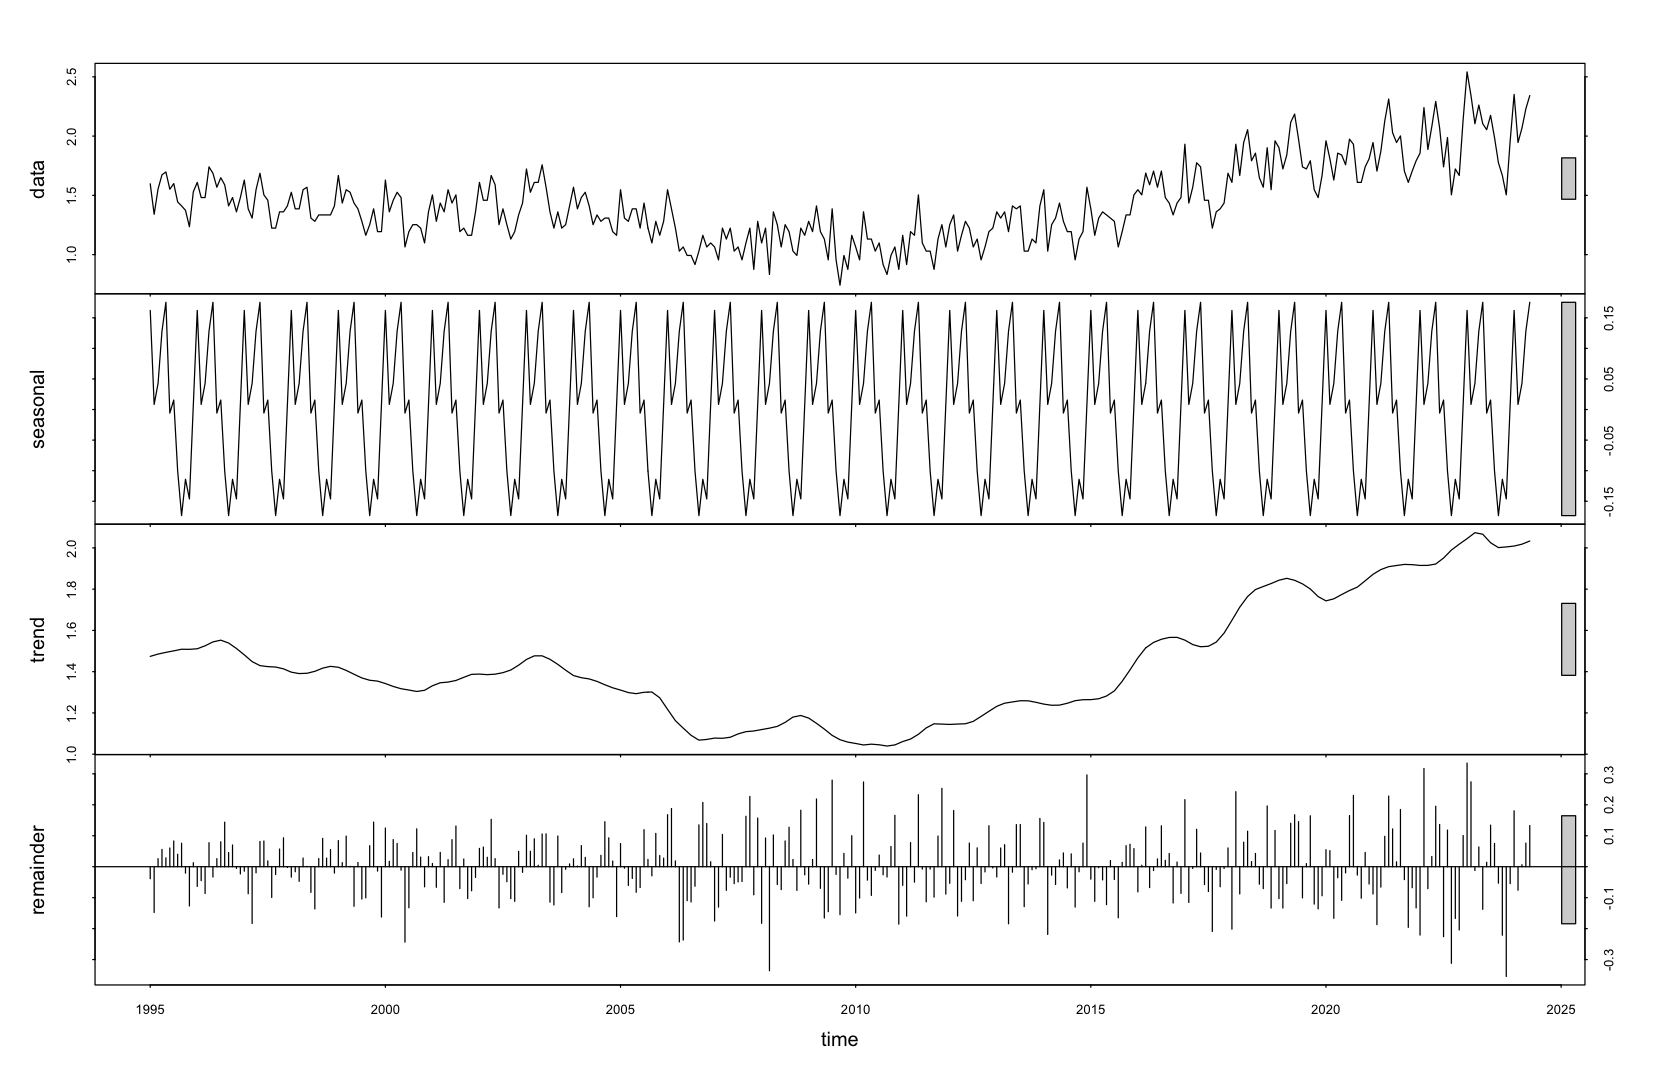

In [86]:
decomposed = stl(data_train, s.window = "periodic")

plot(decomposed)

In [87]:
forecast_stl_arima = stlf(
                        data_train, 
                        method = "arima",
                        h = n - n_train,
                        level = c(80, 95),
                        )


	Ljung-Box test

data:  Residuals from STL +  ARIMA(0,1,1)
Q* = 43.876, df = 23, p-value = 0.005443

Model df: 1.   Total lags used: 24



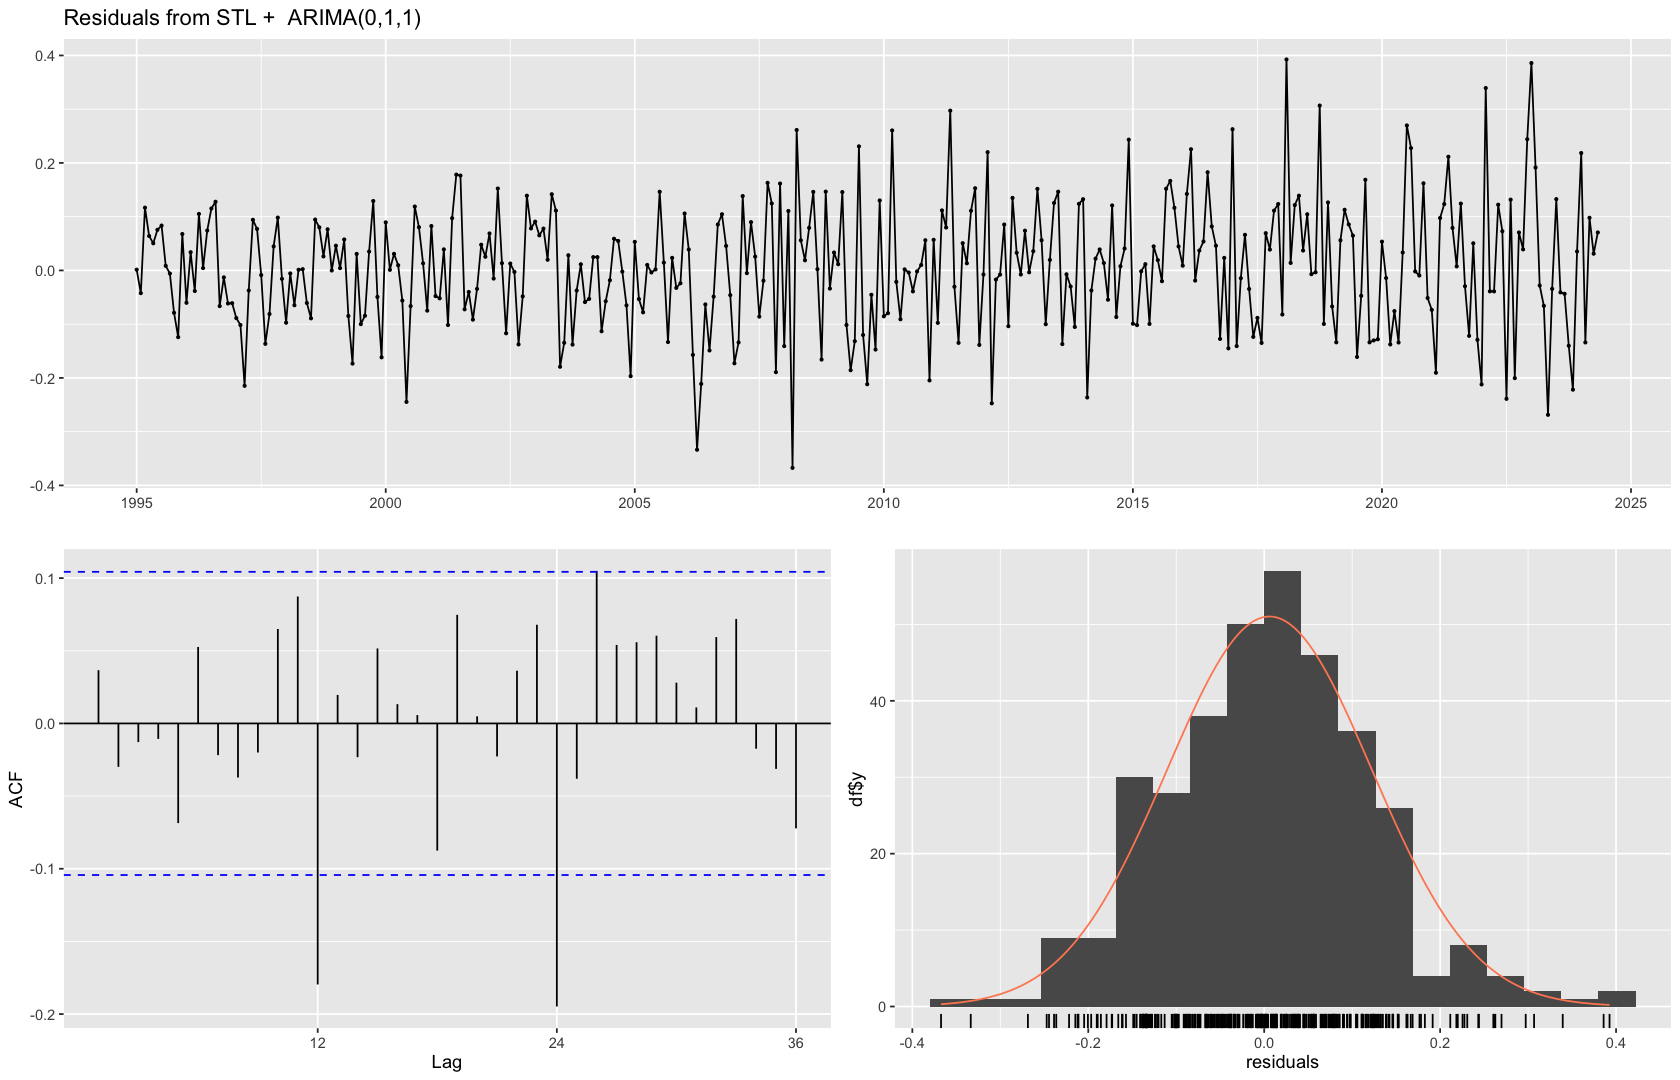

In [88]:
checkresiduals(forecast_stl_arima)

### compare raw data (black) vs. fitted model (red)

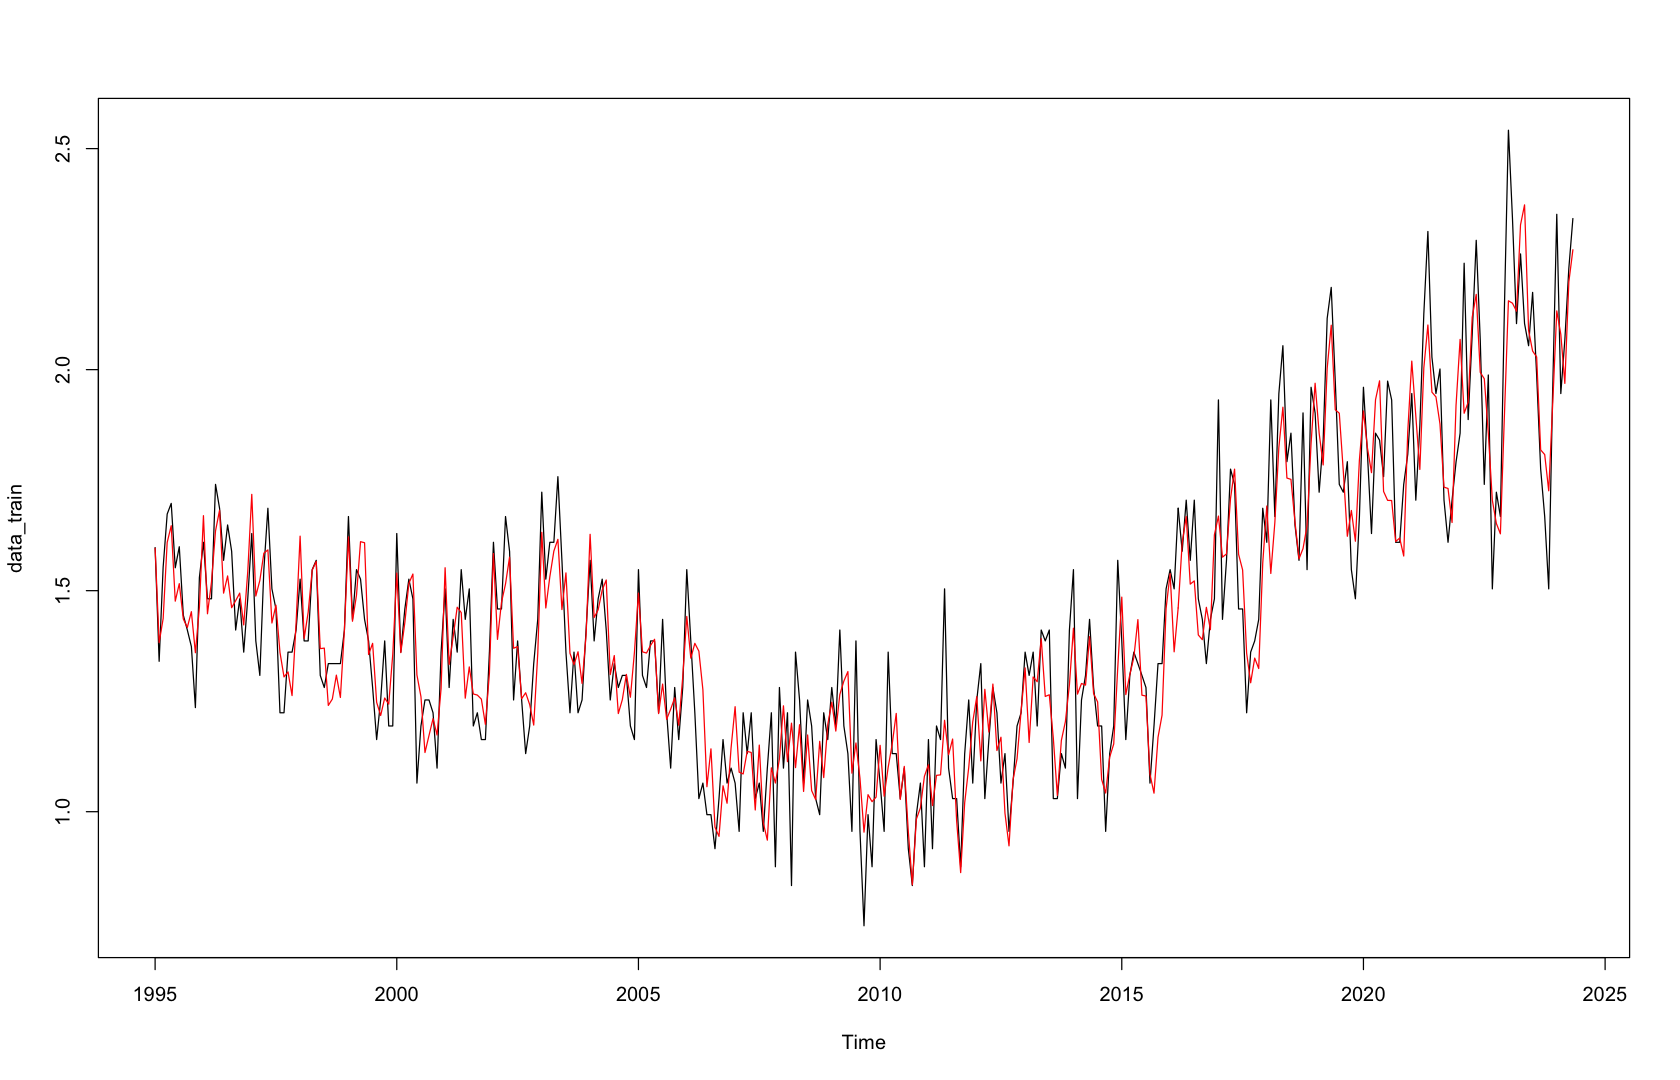

In [98]:
plot(data_train, type = "l")
lines(forecast_stl_arima$fitted, col = "red")

### forecast fitted STL-ARIMA model

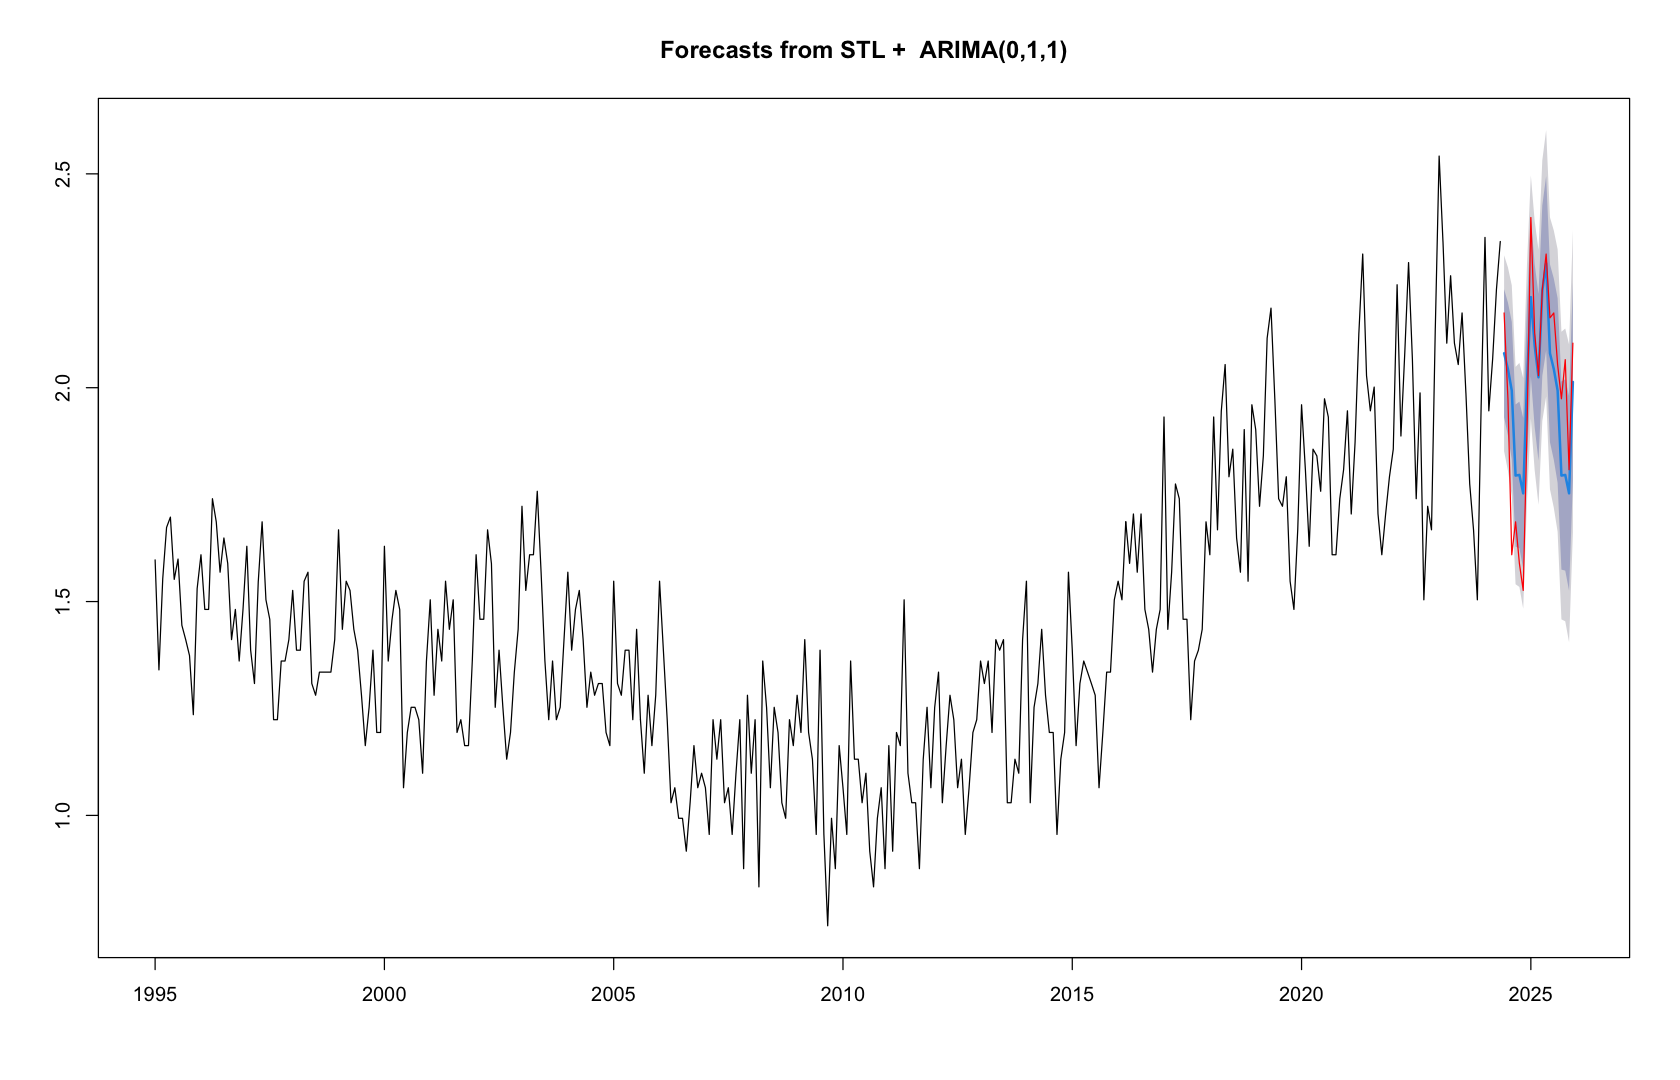

In [89]:
plot(forecast_stl_arima)
lines(data_test, col = 'red')

***

## ETS-model

In [90]:
ets_model <- ets(data_train)

ets_model

ETS(M,N,M) 

Call:
ets(y = data_train)

  Smoothing parameters:
    alpha = 0.21 
    gamma = 1e-04 

  Initial states:
    l = 1.4813 
    s = 1.0078 0.9069 0.9235 0.8768 0.9245 1.0139
           0.9923 1.1219 1.0796 1.0384 1.0037 1.1107

  sigma:  0.0956

     AIC     AICc      BIC 
666.9640 668.3883 724.9610 


	Ljung-Box test

data:  Residuals from ETS(M,N,M)
Q* = 19.543, df = 24, p-value = 0.7224

Model df: 0.   Total lags used: 24



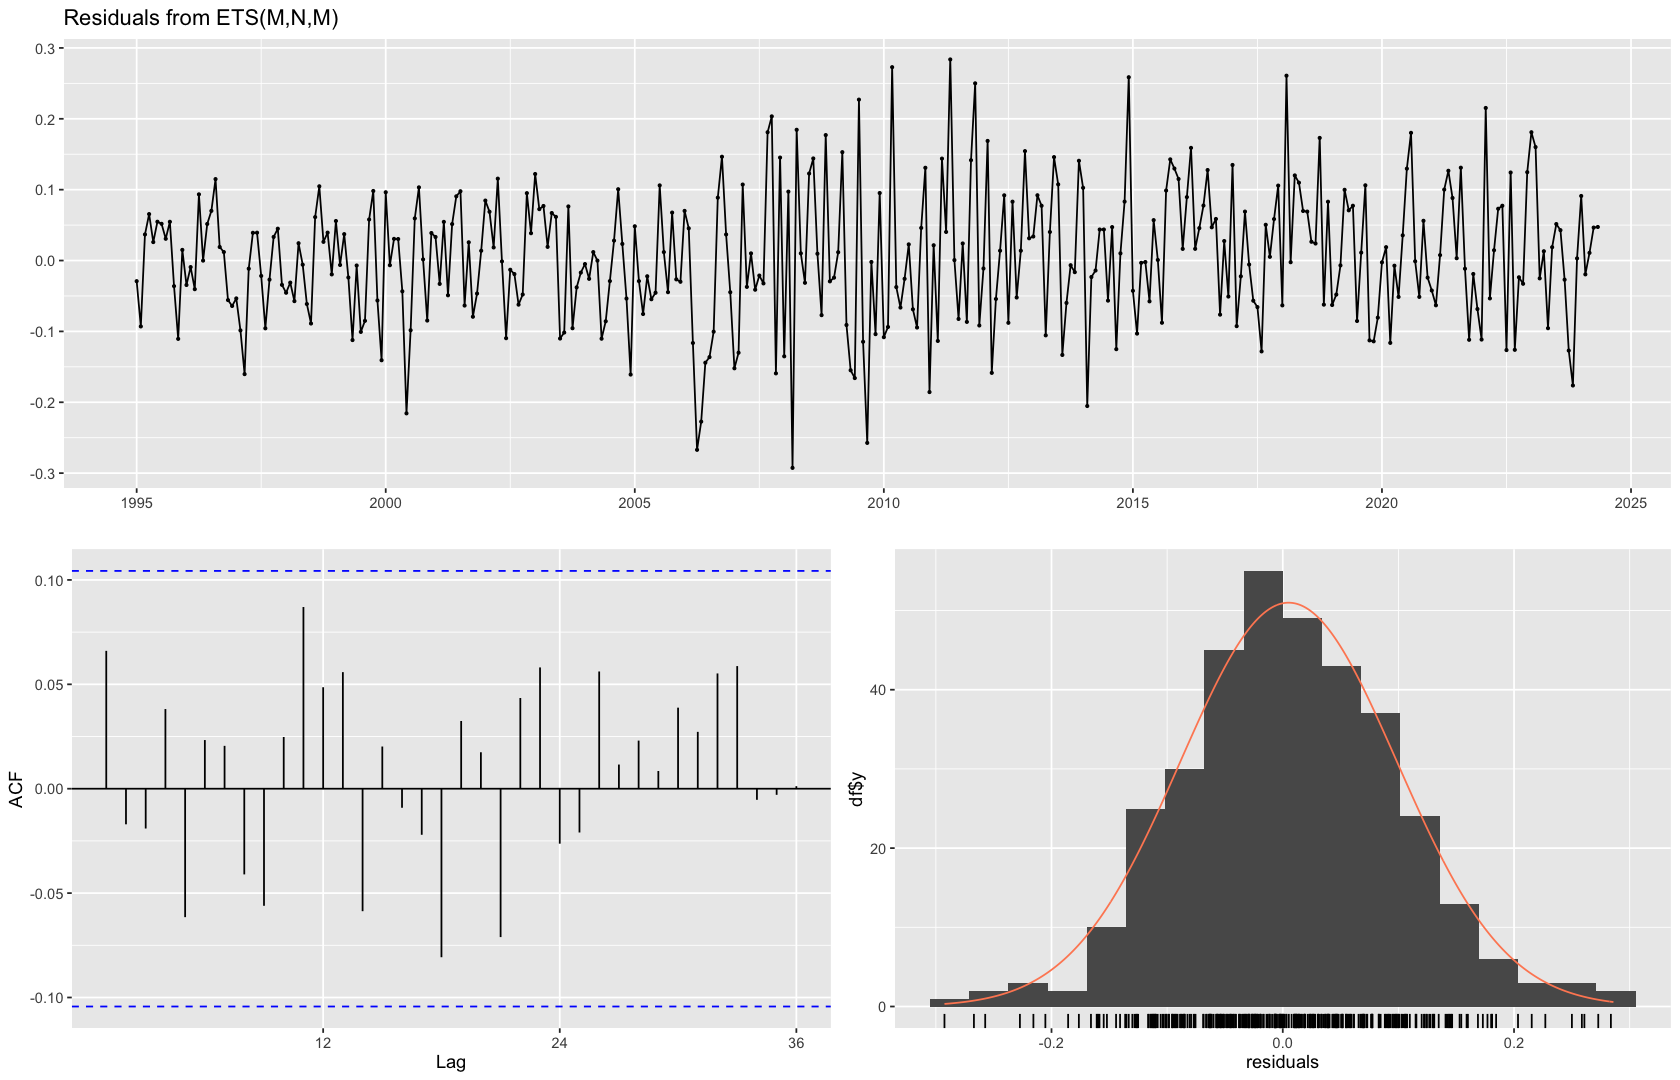

In [91]:
checkresiduals(ets_model)

### compare raw data (black) vs. fitted model (red)

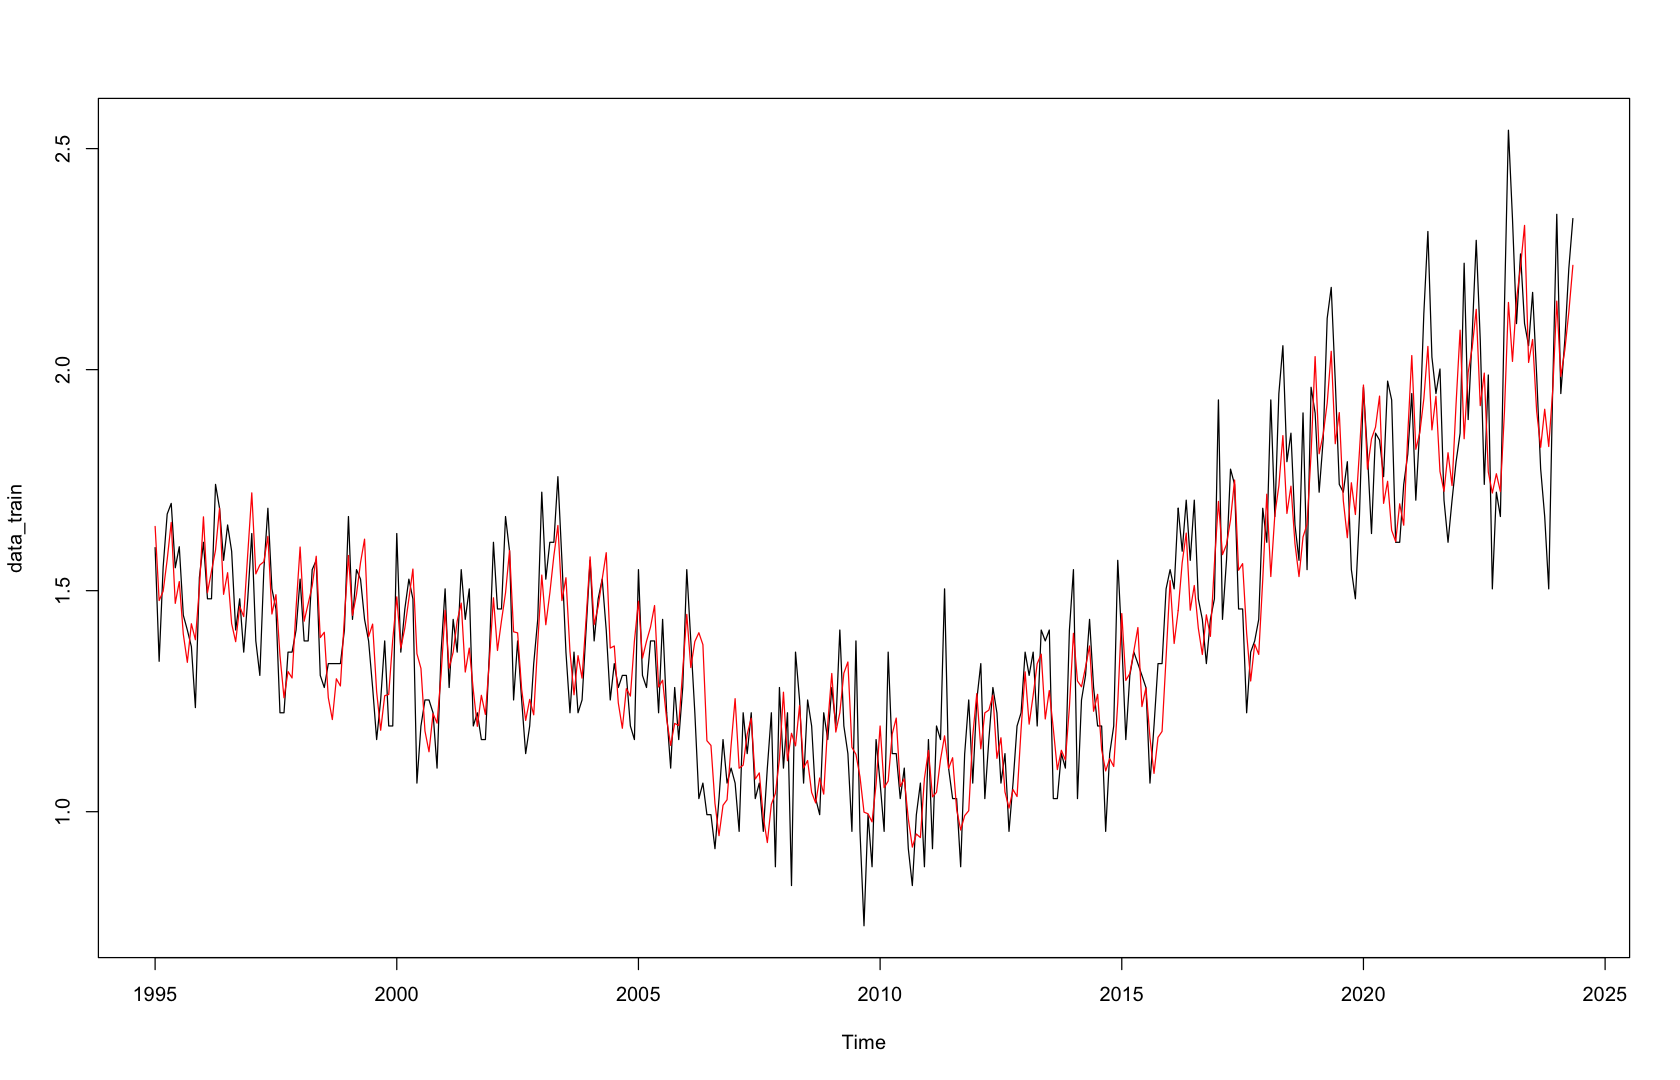

In [97]:
plot(data_train, type = "l")
lines(ets_model$fitted, col = "red")

### forecast fitted ETS model

In [93]:
forecast_ets <- forecast(ets_model, h = n - n_train) 

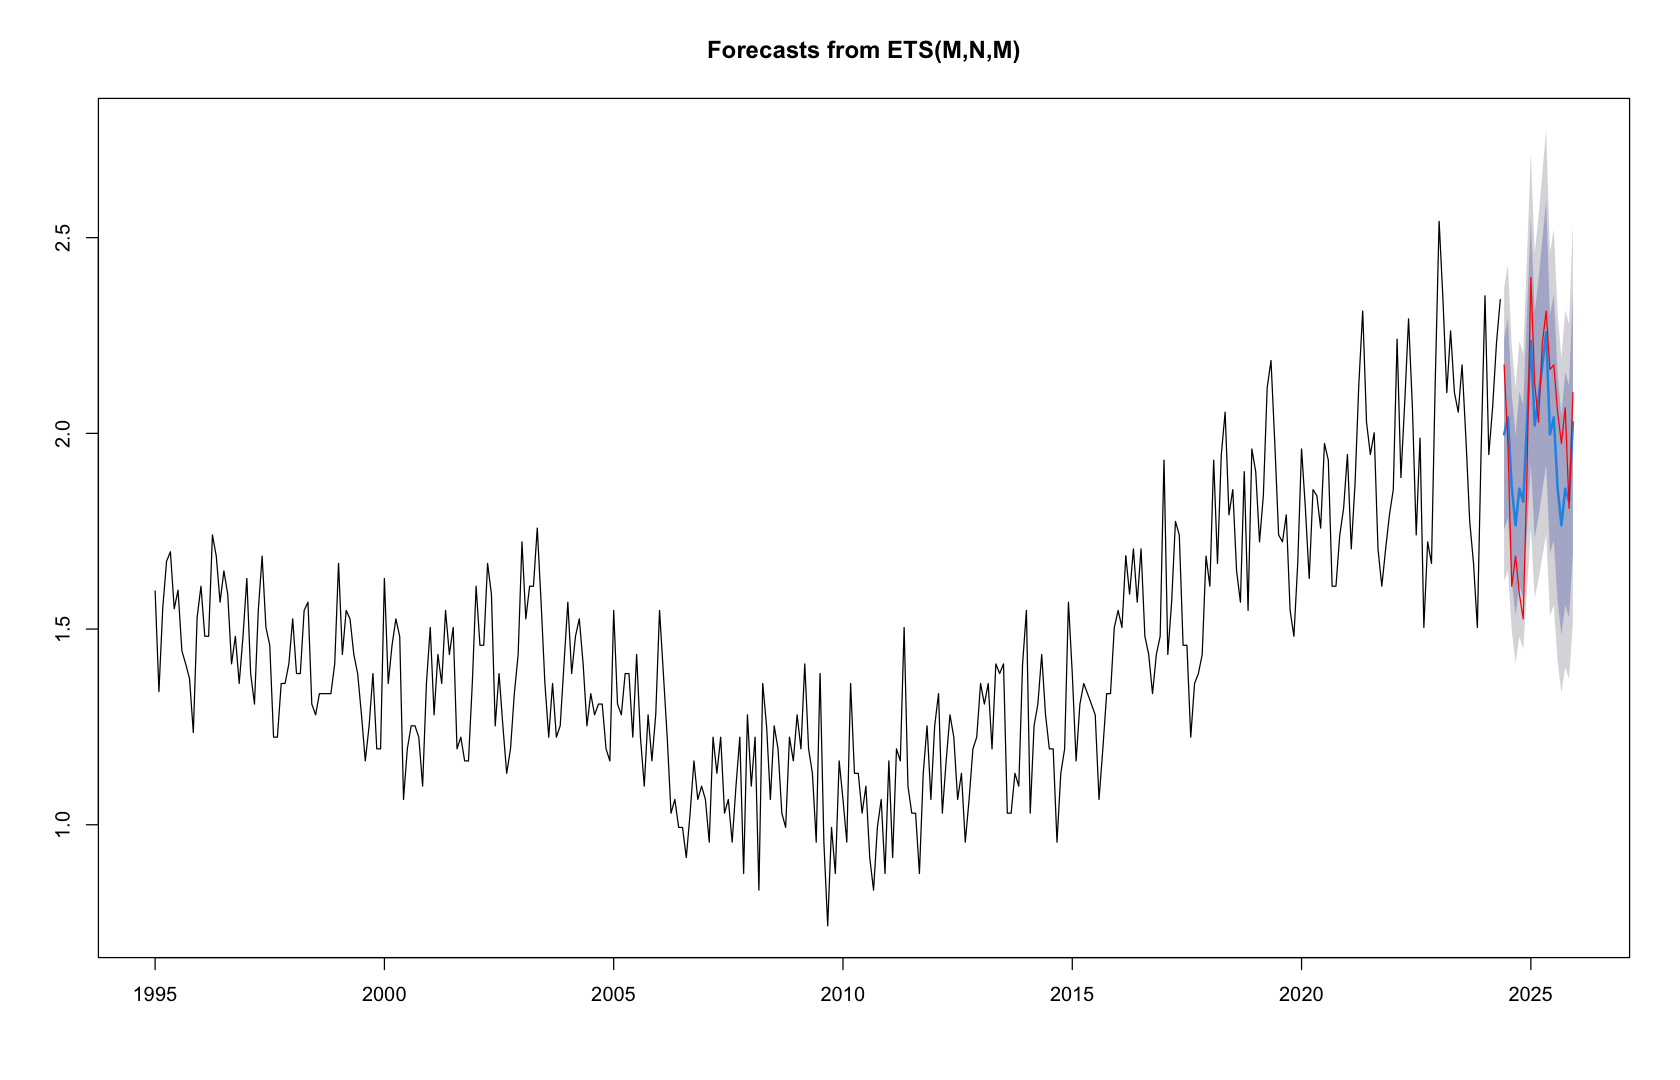

In [94]:
plot(forecast_ets)
lines(data_test, col = 'red')

## Compare accuracies of STL-ARIMA vs. ETS models

In [96]:
accuracy(forecast_stl_arima, data_test)
accuracy(forecast_ets, data_test)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,0.006008718,0.1165004,0.09092629,-0.2959028,6.57364,0.6253050,0.03662054,NA
Test set,0.005323110,0.1555150,0.12185730,-0.5514332,6.55907,0.8380192,0.52631798,0.7079476


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,0.007311984,0.1301509,0.1029817,-0.37917402,7.437569,0.7082110,0.1113681,NA
Test set,0.019651690,0.1633465,0.1428766,0.07890843,7.537705,0.9825703,0.5755302,0.7342297


***

# Summary:
- STL-ARIMA model outperforms the ETS model by essentially every relevant test-set measure. 
- A high autocorrelation of residuals in the test set for both models, which indicates how the two models failed to explain patterns in the test data. Adjustment of the models is likely needed to increase performance.

***